<a href="https://colab.research.google.com/github/EthanJF-Physics/MAT422/blob/main/MAT422HW4EthanF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All of the definitions, theorems, and lemmas used in this homework are drawn from the first edition of Mathematical Methods in Data Science (January 6, 2023), published by Elsevier and authored by Jingli Ren and Haiyan Wang.

## 2.2 Probability Distribution

> "A probability distribution is the mathematical function that gives the probabilities of occurrence of different possible outcomes for an experiment."

* **Discrete Probability Distributions**: Used when the outcomes are countable values (e.g., rolling a die, coin flips). The probabilities are defined by a **Probability Mass Function (PMF)**, where the sum of all probabilities equals 1:
  $$\sum_{i} P(X = x_i) = 1$$

* **Continuous Probability Distributions**: Used when the outcomes can take any value within a continuous range (e.g., height, time, temperature). The probabilities are defined by a **Probability Density Function (PDF)**, where the total area under the curve equals 1:
  $$\int_{-\infty}^{\infty} f(x) \, dx = 1$$


In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import scipy as scipy
import random
import math
import pandas as pd
from scipy import stats
from scipy.integrate import quad

{1: 128, 2: 172, 3: 174, 4: 176, 5: 177, 6: 173}
1 0.128
2 0.172
3 0.174
4 0.176
5 0.177
6 0.173
Total Probability: 1.0
Is it close to 1?
Yes


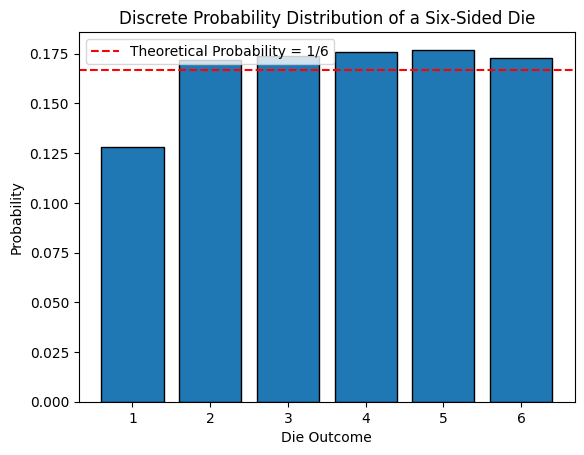

In [2]:
# Discrete
counts = {
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0,
    6: 0
}
# Roll the die 1000 times
for i in range(1000):
    roll = random.randint(1, 6)
    counts[roll] += 1
print(counts)
# Calculate probabilities
probabilities = {}
for outcome, count in counts.items():
    probability = count / 1000
    probabilities[outcome] = probability
    print(outcome, probability)
# Add all probabilities
P_Total = sum(probabilities.values())
print("Total Probability:", P_Total)
print("Is it close to 1?")
if math.isclose(P_Total, 1):
    print("Yes")
else:
    print("NO?????")

# Plot the discrete probability distribution
plt.bar(
    probabilities.keys(),
    probabilities.values(),
    edgecolor="black"
)

plt.xlabel("Die Outcome")
plt.ylabel("Probability")
plt.title("Discrete Probability Distribution of a Six-Sided Die")

# Theoretical probability for comparison
plt.axhline(
    y=1/6,
    color="red",
    linestyle="--",
    label="Theoretical Probability = 1/6"
)

plt.legend()
plt.show()

First 10 values: [0.42291809 0.87955168 0.2736484  0.8704568  0.3537784  0.2819052
 0.14317676 0.04793299 0.52322412 0.65260448]
0.0 - 0.1: 0.102
0.1 - 0.2: 0.107
0.2 - 0.3: 0.101
0.3 - 0.4: 0.113
0.4 - 0.5: 0.104
0.5 - 0.6: 0.094
0.6 - 0.7: 0.098
0.7 - 0.8: 0.083
0.8 - 0.9: 0.091
0.9 - 1.0: 0.107
Total Probability: 0.9999999999999999
Is it close to 1?
Yes


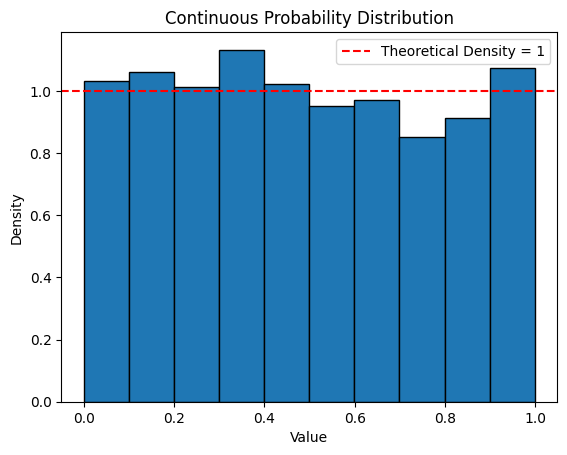

In [3]:
# Continuous
# Generate 1000 continuous random values between 0 and 1
data = np.random.uniform(0, 1, 1000)
print("First 10 values:", data[:10])
# Create bins
bins = np.linspace(0, 1, 11)  # 10 intervals
counts, bin_edges = np.histogram(data, bins=bins)
# Calculate probabilities
probabilities = counts / 1000
# Print probability for each interval
for i in range(len(probabilities)):
    print(
        f"{bin_edges[i]:.1f} - {bin_edges[i+1]:.1f}: "
        f"{probabilities[i]}"
    )
# Add all probabilities
P_Total = sum(probabilities)
print("Total Probability:", P_Total)
print("Is it close to 1?")
if math.isclose(P_Total, 1):
    print("Yes")
else:
    print("NO?????")
plt.hist(
    data,
    bins=10,
    density=True,
    edgecolor="black"
)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Continuous Probability Distribution")
# Theoretical density for Uniform(0,1)
plt.axhline(
    y=1,
    color="red",
    linestyle="--",
    label="Theoretical Density = 1"
)
plt.legend()
plt.show()

### 2.2.1 Probability Axioms

> **Definition 2.2.1:** The **sample space** of an experiment, denoted by $S$, is the set of all possible outcomes of that experiment.

> **Definition 2.2.2:** An **event** is any collection (subset) of outcomes contained in the sample space $S$.

> **Definition 2.2.3:** Given an experiment and a sample space $S$, the **probability distribution** is a function which assigns to each event $A$ a number $P(A)$, called the probability of the event $A$. This number gives a precise measure of the chance that $A$ will occur.

The probability assignments must satisfy the following **axioms (basic properties) of probability**:

1. **Non-negativity:** For any event $A$,
   $$1 \ge P(A) \ge 0$$
2. **Certainty:** For the entire sample space $S$,
   $$P(S) = 1$$
3. **Countable Additivity:** If $A_1, A_2, A_3, \dots$ is an infinite collection of disjoint (mutually exclusive) events, then:
   $$P(A_1 \cup A_2 \cup A_3 \cup \dots) = \sum_{i=1}^{\infty} P(A_i)$$
4. **Complement Rule:** For any event $A$ and its complement $A'$,
   $$P(A) + P(A') = 1 \implies P(A) = 1 - P(A')$$
5. **Addition Rule for Mutually Exclusive Events:** When events $A$ and $B$ are mutually exclusive:
   $$P(A \cup B) = P(A) + P(B)$$
6. **General Addition Rule:** For any two events $A$ and $B$:
   $$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$

***

For any compound event $A$, let $N(A)$ denote the number of outcomes contained in $A$. The probability of event $A$ is given by:
$$P(A) = \frac{N(A)}{N}$$

In [6]:
# Sample Set S, Event A, Probability of A = P(A)
S = []
A = []
P_a = 0

def check_non_negativity(P_a):
    return 0 <= P_a <= 1
def sum_probabilities(probabilities):
    return sum(probabilities)
def complement_probability(P_A):
    return 1 - P_A
def mutually_exclusive_addition(P_A, P_B):
    return P_A + P_B
def general_addition(P_A, P_B, P_A_intersection_B):
    return P_A + P_B - P_A_intersection_B
# EQUALLY LIKELY OUTCOMES
N = len(S)
N_a = len(A)
if N > 0:
    P_aN = N_a / N
else:
    P_aN = 0

# EXAMPLE: Rolling a fair six-sided die
# Sample space
S = [1, 2, 3, 4, 5, 6]
# Event A = rolling an even number
A = [2, 4, 6]
# Total number of outcomes
N = len(S)
# Number of outcomes in A
N_a = len(A)
# Probability of A
P_a = N_a / N
print("N =", N)
print("N(A) =", N_a)
print("P(A) =", P_a)
# CHECKS FOR EXAMPLE
# Check 1: Non-negativity
print("\nCheck 1: Non-negativity")
print("0 <= P(A) <= 1")
print("0 <= ", P_a, "<= 1")
print("Holds:", check_non_negativity(P_a))
# Check 2: Certainty
P_S = len(S) / N
print("\nCheck 2: Certainty")
print("P(S) =", P_S)
print("Expected P(S) = 1")
print("Holds:", math.isclose(P_S, 1))
# Check 3: Additivit (Each individual outcome has probability 1/6.)
P_1 = 1 / N
P_2 = 1 / N
P_3 = 1 / N
P_4 = 1 / N
P_5 = 1 / N
P_6 = 1 / N
probabilities = [
    P_1,
    P_2,
    P_3,
    P_4,
    P_5,
    P_6
]
P_total = sum_probabilities(probabilities)
print("\nCheck 3: Additivity")
print("Individual probabilities =", probabilities)
print("Sum of probabilities =", P_total)
print("P(S) =", P_S)
print("Holds:", math.isclose(P_total, P_S))
# Check 4: Complement Rule
P_A = P_a
P_A_complement = complement_probability(P_A)
print("\nCheck 4: Complement Rule")
print("P(A) =", P_A)
print("P(A') =", P_A_complement)
print("P(A) + P(A') =", P_A + P_A_complement)
print(
    "Holds:",
    math.isclose(P_A + P_A_complement, 1)
)
# Check 5: Mutually Exclusive Addition Rule
# B = rolling a 1
# C = rolling a 2
B = [1]
C = [2]
P_B = len(B) / N
P_C = len(C) / N
P_B_union_C = mutually_exclusive_addition(
    P_B,
    P_C
)
print("\nCheck 5: Mutually Exclusive Addition Rule")
print("P(B) =", P_B)
print("P(C) =", P_C)
print("P(B) + P(C) =", P_B_union_C)
print("P(B U C) =", P_B_union_C)
print(
    "Holds:",
    math.isclose(P_B_union_C, 2 / N)
)
# Check 6: General Addition Rule
#
# D = {2, 4, 6}
# E = {4, 5, 6}
# D ∩ E = {4, 6}
D = [2, 4, 6]
E = [4, 5, 6]
# Find the intersection
D_intersection_E = [
    x for x in D
    if x in E
]
# Calculate individual probabilities
P_D = len(D) / N
P_E = len(E) / N
# Calculate intersection probability
P_D_intersection_E = len(D_intersection_E) / N
P_D_union_E = general_addition(
    P_D,
    P_E,
    P_D_intersection_E
)
print("\nCheck 6: General Addition Rule")
print("P(D) =", P_D)
print("P(E) =", P_E)
print("P(D ∩ E) =", P_D_intersection_E)
print("P(D U E) =", P_D_union_E)
# Directly calculate P(D U E) for comparison
D_union_E = list(set(D) | set(E))
P_D_union_E_direct = len(D_union_E) / N
print("Direct P(D U E) =", P_D_union_E_direct)
print(
    "Holds:",
    math.isclose(
        P_D_union_E,
        P_D_union_E_direct
    )
)

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print("Check 1 - Non-negativity:           ",
      check_non_negativity(P_a))
print("Check 2 - Certainty:                ",
      math.isclose(P_S, 1))
print("Check 3 - Additivity:               ",
      math.isclose(P_total, P_S))
print("Check 4 - Complement Rule:          ",
      math.isclose(P_A + P_A_complement, 1))
print("Check 5 - Mutually Exclusive Rule:  ",
      math.isclose(P_B_union_C, 2 / N))
print("Check 6 - General Addition Rule:    ",
      math.isclose(
          P_D_union_E,
          P_D_union_E_direct
      ))
print("=" * 60)


N = 6
N(A) = 3
P(A) = 0.5

Check 1: Non-negativity
0 <= P(A) <= 1
0 <=  0.5 <= 1
Holds: True

Check 2: Certainty
P(S) = 1.0
Expected P(S) = 1
Holds: True

Check 3: Additivity
Individual probabilities = [0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666]
Sum of probabilities = 1.0
P(S) = 1.0
Holds: True

Check 4: Complement Rule
P(A) = 0.5
P(A') = 0.5
P(A) + P(A') = 1.0
Holds: True

Check 5: Mutually Exclusive Addition Rule
P(B) = 0.16666666666666666
P(C) = 0.16666666666666666
P(B) + P(C) = 0.3333333333333333
P(B U C) = 0.3333333333333333
Holds: True

Check 6: General Addition Rule
P(D) = 0.5
P(E) = 0.5
P(D ∩ E) = 0.3333333333333333
P(D U E) = 0.6666666666666667
Direct P(D U E) = 0.6666666666666666
Holds: True

FINAL SUMMARY
Check 1 - Non-negativity:            True
Check 2 - Certainty:                 True
Check 3 - Additivity:                True
Check 4 - Complement Rule:           True
Check 5 - Mutually Excl

### 2.2.2 Conditional Probability

Conditional probability is defined as the likelihood of an event or outcome occurring, based on the occurrence of a previous event or outcome. The conditional probability of $A$ given $B$ is proportional to $P(A \cap B)$.

> **Definition 2.2.5:** For any two events $A$ and $B$ with $P(B) > 0$, the conditional probability of $A$ given that $B$ has occurred is defined by:
>
> $$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

> **Definition 2.2.6:** Two events $A$ and $B$ are **independent** if:
>
> $$P(A \mid B) = P(A) \quad \text{or} \quad P(A \cap B) = P(A) \cdot P(B)$$
>
> They are considered **dependent** otherwise.

> **Definition 2.2.7:** Events $A_1, A_2, \dots, A_n$ are **mutually independent** if for every $k$ (where $k = 2, 3, \dots, n$) and every subset of indices $i_1, i_2, \dots, i_k$:
>
> $$P(A_{i_1} \cap A_{i_2} \cap \dots \cap A_{i_k}) = P(A_{i_1}) \cdot P(A_{i_2}) \cdots P(A_{i_k})$$


In [7]:
# Total deterministic sample space of a single die
die = np.array([1, 2, 3, 4, 5, 6])
# --- Define Events ---
event_A = (die % 2 == 0)       # Even numbers: {2, 4, 6}
event_B = (die >= 4)           # High numbers: {4, 5, 6}
# --- Calculate Base Probabilities ---
p_A = np.mean(event_A)         # 3/6 = 0.50
p_B = np.mean(event_B)         # 3/6 = 0.50
p_A_and_B = np.mean(event_A & event_B)  # Even AND >= 4: {4, 6} -> 2/6 = 0.3333

# --- 1. Test Definition 2.2.5: P(A|B) = P(A ∩ B) / P(B) ---
# Direct physical count: filter universe down to B, see how many are even
p_A_given_B_empirical = np.mean(die[event_B] % 2 == 0)  # {4, 6} out of {4, 5, 6} -> 2/3
# Formula math
p_A_given_B_formula = p_A_and_B / p_B
check_def_2_2_5 = np.isclose(p_A_given_B_empirical, p_A_given_B_formula)
print("--- Testing Definition 2.2.5 ---")
print(f"Empirical P(A|B): {p_A_given_B_empirical:.4f}")
print(f"Formula   P(A|B): {p_A_given_B_formula:.4f}")
print(f"Does Definition 2.2.5 hold true? -> {check_def_2_2_5}\n")

# --- 2. Test Multiplication Rule: P(A ∩ B) = P(A|B) * P(B) ---
p_intersection_via_rule = p_A_given_B_empirical * p_B
check_multiplication_rule = np.isclose(p_A_and_B, p_intersection_via_rule)
print("--- Testing Multiplication Rule ---")
print(f"Actual P(A ∩ B):        {p_A_and_B:.4f}")
print(f"Multiplication Rule:    {p_intersection_via_rule:.4f}")
print(f"Does Multiplication Rule hold true? -> {check_multiplication_rule}\n")

# --- 3. Test Definition 2.2.6: Independence vs Dependence ---
# If independent, P(A ∩ B) must equal P(A) * P(B)
p_A_times_p_B = p_A * p_B
are_independent = np.isclose(p_A_and_B, p_A_times_p_B)
print("--- Testing Definition 2.2.6 ---")
print(f"P(A ∩ B)    = {p_A_and_B:.4f}")
print(f"P(A) * P(B) = {p_A_times_p_B:.4f}")
print(f"Are Events A and B Independent? -> {are_independent} (They are DEPENDENT)")
# I know from the example this is dpendent, if you did not know then add a little more

--- Testing Definition 2.2.5 ---
Empirical P(A|B): 0.6667
Formula   P(A|B): 0.6667
Does Definition 2.2.5 hold true? -> True

--- Testing Multiplication Rule ---
Actual P(A ∩ B):        0.3333
Multiplication Rule:    0.3333
Does Multiplication Rule hold true? -> True

--- Testing Definition 2.2.6 ---
P(A ∩ B)    = 0.3333
P(A) * P(B) = 0.2500
Are Events A and B Independent? -> False (They are DEPENDENT)


### 2.2.3 Discrete Random Variables

A random variable is understood as a measurable function defined on a probability space that maps from the sample space to the real numbers.

> **Definition 2.2.9:** A **discrete random variable** is a random variable whose possible values either constitute a finite set or else can be listed in an infinite sequence.
>
> A random variable is **continuous** if both of the following apply:
> 1. Its set of possible values consists of all numbers in a single interval on the number line.
> 2. $P(X = c) = 0$ for any individual possible value $c$.

> **Definition 2.2.10:** The **probability distribution** or **probability mass function (pmf)** $p(x)$ of a discrete random variable is defined for every number $x$ by:
>
> $$p(x) = P(X = x) = P(\{\text{all } s \in S : X(s) = x\})$$
>
> The pmf must satisfy $\sum p(x) = 1$ and $p(x) \ge 0$ for all $x$.

> **Definition 2.2.11:** The **cumulative distribution function (cdf)** $F(x)$ of a discrete random variable $X$ with pmf $p(x)$ is defined for every number $x$ by:
>
> $$F(x) = P(X \le x) = \sum_{y:y \le x} p(y)$$


### 2.2.3.1 The Expected Value and Variance of $X$

The expected value of a random variable $X$ is a generalization of the weighted average, and is intuitively the arithmetic mean of a large number of independent realizations of $X$.

> **Definition 2.2.14:** Let $X$ be a discrete random variable with a set of possible values $D$ and pmf $p(x)$. The **expected value** or **mean value** of $X$, denoted by $E(X)$, $\mu_X$, or simply $\mu$, is defined as:
>
> $$E(X) = \mu_X = \sum_{x \in D} x \cdot p(x)$$

> **Proposition 2.2.16:** If the random variable $X$ has a set of possible values $D$ and pmf $p(x)$, then the **expected value of any function** $h(X)$, denoted by $E[h(X)]$ or $\mu_{h(X)}$, is computed by:
>
> $$E[h(X)] = \sum_{x \in D} h(x) \cdot p(x)$$
>
> In particular, expectation is a linear operator, meaning for any constants $a$ and $b$:
>
> $$E(aX + b) = a \cdot E(X) + b$$

#### Variance and Standard Deviation
Variances measure how far a set of numbers is spread out from their average value.

> **Definition 2.2.17:** Let $X$ have pmf $p(x)$ and expected value $\mu$. Then the **variance** of $X$, denoted by $V(X)$, $\sigma^2_X$, or simply $\sigma^2$, is defined as:
>
> $$V(X) = \sum_{x \in D} (x - \mu)^2 \cdot p(x) = E[(X - \mu)^2]$$
>
> The **standard deviation (SD)** of $X$ is the positive square root of the variance:
>
> $$\sigma_X = \sqrt{\sigma^2_X}$$



In [8]:
class DiscreteRandomVariable:
    def __init__(self, pmf):
        self.pmf = pmf

        # Check that probabilities are not negative
        if any(p < 0 for p in pmf.values()):
            raise ValueError("Probabilities cannot be negative.")

        # Check that probabilities sum to 1
        if abs(sum(pmf.values()) - 1) > 1e-12:
            raise ValueError("Probabilities must sum to 1.")

    def probability(self, x):
        """Return P(X = x)."""
        return self.pmf.get(x, 0)

    def cdf(self, x):
        """Return P(X <= x)."""
        return sum(
            probability
            for value, probability in self.pmf.items()
            if value <= x
        )

    def expected_value(self):
        """Return E(X)."""
        return sum(
            value * probability
            for value, probability in self.pmf.items()
        )

    def expected_function(self, h):
        """Return E[h(X)]."""
        return sum(
            h(value) * probability
            for value, probability in self.pmf.items()
        )

    def variance(self):
        """Return Var(X)."""
        mu = self.expected_value()

        return sum(
            (value - mu)**2 * probability
            for value, probability in self.pmf.items()
        )

    def standard_deviation(self):
        """Return the standard deviation of X."""
        return math.sqrt(self.variance())


# Create the random variable
X = DiscreteRandomVariable({
    0: 0.2,
    1: 0.5,
    2: 0.3
})
# P(X = 1)
print("Probability of X = 1:", X.probability(1))
# P(X <= 1)
print("Probability of X <= 1:", X.cdf(1))
# E(X)
print("Expected value:", X.expected_value())
# E(X^2)
print("E[X^2]:", X.expected_function(lambda x: x**2))
# Var(X)
print("Variance:", X.variance())
# Standard deviation
print("Standard deviation:", X.standard_deviation())


Probability of X = 1: 0.5
Probability of X <= 1: 0.7
Expected value: 1.1
E[X^2]: 1.7
Variance: 0.49
Standard deviation: 0.7


### 2.2.4 Continuous Random Variables

A random variable $X$ is continuous if its possible values comprise either a single interval on the number line or a union of disjoint intervals.

> **Definition 2.2.20:** Let $X$ be a continuous random variable. Then a **probability distribution** or **probability density function (pdf)** of $X$ is a function $f(x)$ such that for any two numbers $a$ and $b$ with $a \le b$:
>
> $$P(a \le X \le b) = \int_{a}^{b} f(x) \, dx$$
>
> That is, the probability that $X$ takes on a value in the interval $[a, b]$ is the area above this interval and under the graph of the density function. The pdf $f(x)$ must satisfy the following two conditions:
> 1. $f(x) \ge 0$ for all $x$
> 2. $\int_{-\infty}^{\infty} f(x) \, dx = \text{Total area under the entire graph of } f(x) = 1$

### 2.2.4.1 Expected Values and Variances

We define the expected values and variances for continuous random variables analogously to discrete variables, substituting summations with integrations.

> **Definition 2.2.21:** The **expected** or **mean value** of a continuous random variable $X$ with pdf $f(x)$ is:
>
> $$\mu_X = E(X) = \int_{-\infty}^{\infty} x \cdot f(x) \, dx$$

> **Definition 2.2.22:** The **variance** of a continuous random variable $X$ with pdf $f(x)$ and mean $\mu$ is:
>
> $$\sigma^2_X = V(X) = \int_{-\infty}^{\infty} (x - \mu)^2 \cdot f(x) \, dx = E[(X - \mu)^2]$$
>
> The **standard deviation (SD)** of $X$ is $\sigma_X = \sqrt{V(X)}$.

---

#### The Exponential Distribution

> **Definition 2.2.24:** $X$ is said to have an **exponential distribution** with parameter $\lambda$ ($\lambda > 0$) if the pdf of $X$ is:
>
> $$f(x; \lambda) = \begin{cases} \lambda e^{-\lambda x} & x \ge 0 \\ 0 & \text{otherwise} \end{cases}$$

The expected value of an exponentially distributed random variable $X$ is found by evaluating:

$$E(X) = \int_{0}^{\infty} x \lambda e^{-\lambda x} \, dx$$

The results of these integrations yield:

$$\mu = \frac{1}{\lambda} \quad \text{and} \quad \sigma^2 = \frac{1}{\lambda^2}$$

Both the mean and standard deviation of the exponential distribution equal $\frac{1}{\lambda}$.


In [4]:
# Example PDF
def triangular_pdf(x):
    if 0 <= x <= 2:
        return x / 2
    return 0.0
# Check that total probability is 1
total_probability = quad(
    triangular_pdf,
    -float("inf"),
    float("inf")
)[0]
print("=== Example PDF ===")
print("Total Probability:", total_probability)
# Calculate P(1 <= X <= 1.5)
probability = quad(triangular_pdf, 1, 1.5)[0]
print("P(1 <= X <= 1.5):", probability)

# Continuous Random Variable Class
class ContinuousRandomVariable:
    def __init__(
        self,
        pdf,
        lower_bound=-float("inf"),
        upper_bound=float("inf")
    ):
        self.pdf = pdf
        self.a = lower_bound
        self.b = upper_bound

        # Check that the PDF integrates to 1
        total_area = quad(self.pdf, self.a, self.b)[0]

        if abs(total_area - 1) > 1e-4:
            raise ValueError(
                "The PDF must integrate to 1."
            )

    def cdf(self, x):
        """Return P(X <= x)."""

        if x < self.a:
            return 0.0

        if x > self.b:
            return 1.0

        return quad(self.pdf, self.a, x)[0]

    def expected_value(self):
        """Return E(X)."""

        return quad(
            lambda x: x * self.pdf(x),
            self.a,
            self.b
        )[0]

    def expected_function(self, h):
        """Return E[h(X)]."""

        return quad(
            lambda x: h(x) * self.pdf(x),
            self.a,
            self.b
        )[0]

    def variance(self):
        """Return Var(X)."""

        mu = self.expected_value()

        return quad(
            lambda x: (x - mu) ** 2 * self.pdf(x),
            self.a,
            self.b
        )[0]

    def standard_deviation(self):
        """Return the standard deviation of X."""

        return math.sqrt(self.variance())

# Exponential Distribution
lam = 0.5
def exponential_pdf(x):
    if x >= 0:
        return lam * math.exp(-lam * x)
    return 0.0
X = ContinuousRandomVariable(
    exponential_pdf,
    lower_bound=0,
    upper_bound=float("inf")
)
# Test Exponential Distribution
print("\n=== Exponential Distribution ===")
print("Lambda (λ):", lam)
# CDF
P_X_less_than_2 = X.cdf(2)
print("P(X <= 2):", P_X_less_than_2)
# Expected value
expected_value = X.expected_value()
print("E(X):", expected_value)
# E(X²)
second_moment = X.expected_function(lambda x: x ** 2)
print("E(X²):", second_moment)
# Variance
variance = X.variance()
print("Variance:", variance)
# Standard deviation
standard_deviation = X.standard_deviation()
print("Standard deviation:", standard_deviation)

# Validate Results
theoretical_mean = 1 / lam
theoretical_variance = 1 / (lam ** 2)
theoretical_std = 1 / lam
print("\n=== Validation ===")
print(
    "Mean correct:",
    math.isclose(expected_value, theoretical_mean)
)
print(
    "Variance correct:",
    math.isclose(variance, theoretical_variance)
)
print(
    "Standard deviation correct:",
    math.isclose(standard_deviation, theoretical_std)
)

=== Example PDF ===
Total Probability: 0.9999999999999969
P(1 <= X <= 1.5): 0.3125

=== Exponential Distribution ===
Lambda (λ): 0.5
P(X <= 2): 0.6321205588285578
E(X): 1.9999999999999998
E(X²): 8.0
Variance: 4.0
Standard deviation: 2.0

=== Validation ===
Mean correct: True
Variance correct: True
Standard deviation correct: True


### 2.2.4.2 The Normal Distribution

Normal distributions are often used in the natural and social sciences to represent real-valued random variables whose distributions are not known.

> **Definition 2.2.25:** A continuous random variable $X$ is said to have a **normal distribution** with parameters $\mu$ and $\sigma$ (or $\mu$ and $\sigma^2$), where $-\infty < \mu < \infty$ and $\sigma > 0$, if the pdf of $X$ is:
>
> $$f(x; \mu, \sigma) = \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{(x-\mu)^2}{2\sigma^2}} \quad -\infty < x < \infty$$

The computation of $P(a \le X \le b)$ when $X$ is a normal random variable requires evaluating the definite integral:

$$P(a \le X \le b) = \int_{a}^{b} \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{(x-\mu)^2}{2\sigma^2}} \, dx$$

---

#### The Standard Normal Distribution

> **Definition 2.2.26:** The normal distribution with parameter values $\mu = 0$ and $\sigma = 1$ is called the **standard normal distribution**.
>
> A random variable having a standard normal distribution is called a **standard normal random variable** and is denoted by $Z$. The pdf of $Z$ is:
>
> $$f(z; 0, 1) = \frac{1}{\sqrt{2\pi}} e^{-\frac{z^2}{2}} \quad -\infty < z < \infty$$


* **Standard Normal CDF:** The cumulative distribution function (cdf) of $Z$ is denoted by $\Phi(z)$ and represents the area under the curve to the left of $z$:
  $$\Phi(z) = P(Z \le z) = \int_{-\infty}^{z} \frac{1}{\sqrt{2\pi}} e^{-\frac{y^2}{2}} \, dy$$

---

#### Standardization

Any normal distribution $X \sim N(\mu, \sigma^2)$ can be converted into the standard normal variable $Z$ by applying the transformation $Z = \frac{X - \mu}{\sigma}$.

> **Proposition 2.2.27:** If $X$ has a normal distribution with mean $\mu$ and standard deviation $\sigma$, then:
>
> $$Z = \frac{X - \mu}{\sigma}$$
>
> has a standard normal distribution. Consequently, probabilities for $X$ can be computed using $\Phi(z)$:
>
> * $$P(a \le X \le b) = P\left( \frac{a-\mu}{\sigma} \le Z \le \frac{b-\mu}{\sigma} \right) = \Phi\left(\frac{b-\mu}{\sigma}\right) - \Phi\left(\frac{a-\mu}{\sigma}\right)$$
> * $$P(X \le a) = \Phi\left(\frac{a-\mu}{\sigma}\right)$$
> * $$P(X \ge b) = 1 - \Phi\left(\frac{b-\mu}{\sigma}\right)$$


In [5]:
# Normal Distribution Functions
def normal_pdf(x, mu, sigma):
    """Return the PDF of a normal distribution."""
    return (
        1 / (np.sqrt(2 * np.pi) * sigma)
        * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))
    )
def standardize(x, mu, sigma):
    """Convert X to a standard normal Z-score."""

    return (x - mu) / sigma
# Normal Distribution
# X ~ N(10, 2^2)
mu = 10
sigma = 2
# P(8 <= X <= 12)
a = 8
b = 12
z_a = standardize(a, mu, sigma)
z_b = standardize(b, mu, sigma)
P_interval = stats.norm.cdf(z_b) - stats.norm.cdf(z_a)
print("=== Normal Distribution ===")
print(f"Mean (μ): {mu}")
print(f"Standard deviation (σ): {sigma}")
print(f"\nP({a} <= X <= {b}): {P_interval:.4f}")
# P(X <= 8)
P_less_than = stats.norm.cdf(z_a)
print(f"P(X <= {a}): {P_less_than:.4f}")
# P(X >= 12)
P_greater_than = 1 - stats.norm.cdf(z_b)
print(f"P(X >= {b}): {P_greater_than:.4f}")

# Standardization
print("\n=== Standardization ===")
print(f"Z-score for {a}: {z_a:.2f}")
print(f"Z-score for {b}: {z_b:.2f}")
# Check that standardization is correct
print(
    "Standardization for a:",
    math.isclose(z_a, (a - mu) / sigma)
)
print(
    "Standardization for b:",
    math.isclose(z_b, (b - mu) / sigma)
)


# Validate Normal PDF
# Check that the total area under the PDF is 1
total_probability = quad(
    lambda x: normal_pdf(x, mu, sigma),
    -float("inf"),
    float("inf")
)[0]
print("\n=== PDF Validation ===")
print("Total Probability:", total_probability)
print(
    "PDF integrates to 1:",
    math.isclose(total_probability, 1)
)

# Validate Probability Calculations
# Calculate the interval probability directly
direct_probability = quad(
    lambda x: normal_pdf(x, mu, sigma),
    a,
    b
)[0]
print("\n=== Probability Validation ===")
print("Probability using standardization:", P_interval)
print("Probability using direct integration:", direct_probability)
print(
    "Both methods agree:",
    math.isclose(P_interval, direct_probability)
)

=== Normal Distribution ===
Mean (μ): 10
Standard deviation (σ): 2

P(8 <= X <= 12): 0.6827
P(X <= 8): 0.1587
P(X >= 12): 0.1587

=== Standardization ===
Z-score for 8: -1.00
Z-score for 12: 1.00
Standardization for a: True
Standardization for b: True

=== PDF Validation ===
Total Probability: 1.0
PDF integrates to 1: True

=== Probability Validation ===
Probability using standardization: 0.6826894921370859
Probability using direct integration: 0.682689492137086
Both methods agree: True
